In [2]:
!pip install pandas seaborn matplotlib scikit-learn

In [3]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, balanced_accuracy_score

In [4]:
RANDOM_SEED = 37
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [6]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gaia',
    'mixtral-8x7b-instruct': 'Mixtral',
    'sabia-3.1': 'Sabiá',
    'granite-3-3-8b-instruct': 'Granite',
    'gemini-2.5-flash': 'Gemini',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio',
    'kimi-k2-0905': 'Kimi-K2'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gaia,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
1,zero-shot,Mixtral,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabiá,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [7]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [8]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

##### Punchlines Identification

In [9]:
df_punchlines_worse = df_punchlines[
    (df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD) |
    (df_punchlines['dice_similarity'].isna())]
df_punchlines_better = df_punchlines[(df_punchlines['dice_similarity'] >= 0.9) & (df_punchlines['dice_similarity'] < 1)]

In [10]:
df_punchlines_worse.columns

Index(['scenario', 'video_url', 'model_name', 'humorous_text', 'prompt',
       'model_punchlines', 'annotated_punchlines', 'raw_model_output',
       'cleaned_prediction', 'formatted_model_punchlines', 'dice_similarity',
       'is_original_format_valid', 'is_after_treatment_valid'],
      dtype='object')

In [11]:
worse_summary = df_punchlines_worse.groupby(['model_name', 'scenario']).agg({
    'dice_similarity': ['count', 'mean']
}).round(3)

worse_summary.columns = ['count', 'mean_dice']
worse_summary = worse_summary.reset_index()
worse_summary = worse_summary.sort_values(['model_name', 'scenario'])

print(worse_summary)

                             model_name   scenario  count  mean_dice
0             deepseek-r1-0528-qwen3-8b   few-shot     45      0.220
1             deepseek-r1-0528-qwen3-8b  zero-shot     62      0.097
2                      gemini-2.5-flash   few-shot     41      0.265
3                      gemini-2.5-flash  zero-shot     62      0.268
4              gemma-3-gaia-pt-br-4b-it   few-shot    133      0.210
5              gemma-3-gaia-pt-br-4b-it  zero-shot    184      0.238
6   gervasio-7b-portuguese-ptbr-decoder   few-shot      0        NaN
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     10      0.012
8                                 gpt-4   few-shot     33      0.297
9                                 gpt-4  zero-shot     25      0.306
10              granite-3-3-8b-instruct   few-shot     11      0.258
11              granite-3-3-8b-instruct  zero-shot    111      0.258
12                         kimi-k2-0905   few-shot     66      0.251
13                         kimi-k2

In [12]:
df_punchlines_worse['model_name'].unique()

array(['gemma-3-gaia-pt-br-4b-it', 'mixtral-8x7b-instruct', 'sabia-3.1',
       'granite-3-3-8b-instruct', 'gemini-2.5-flash', 'gpt-4',
       'gervasio-7b-portuguese-ptbr-decoder', 'llama-3-405b-instruct',
       'kimi-k2-0905', 'deepseek-r1-0528-qwen3-8b'], dtype=object)

In [13]:
#main_model = ['gemma-3-gaia-pt-br-4b-it']
#main_model = ['gervasio-7b-portuguese-ptbr-decoder']
main_model = ['deepseek-r1-0528-qwen3-8b']

models = ['gemma-3-gaia-pt-br-4b-it', 'gervasio-7b-portuguese-ptbr-decoder', 'deepseek-r1-0528-qwen3-8b']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in main_model:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gemma-3-gaia-pt-br-4b-it
Few-shot: 269 casos
Zero-shot: 187 casos
---
MODELO gervasio-7b-portuguese-ptbr-decoder
Few-shot: 475 casos
Zero-shot: 475 casos
---
MODELO deepseek-r1-0528-qwen3-8b
Few-shot: 422 casos
Zero-shot: 462 casos
---
MODELO deepseek-r1-0528-qwen3-8b
SCENARIO: few-shot
CLEANED PREDICTIONS:
 O texto identifica uma única punchline, que é a parte final do diálogo, quando o delegado provoca uma reinterpretação inesperada. Nesse caso, a punchline é: [Guaguá, Jajá, Bibi, Guru.]
Agora, o texto a ser analisado é:
Texto humorístico: O velhote e o bode
O senhor Jonas, um homem extremamente velho, chega a uma feira para vender ovos, mas é atacado por um bode que foge levando sua cesta.
Pega na barriga e vê que tá farta, mas o bode levou tudo.
Ele fica parado, olhando o buraco na sacola e pensando na perda.
Então o senhor Jonas, com o olhar sereno, diz para si mesmo: "Bem, vou perder meia dúzia de ovos, mas pelo menos não perdi o juizo."
Vale a pena.
Escreva o código que i

In [14]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 34 casos
Zero-shot: 26 casos
---
MODELO gemini-2.5-flash
Few-shot: 43 casos
Zero-shot: 65 casos
---
MODELO sabia-3.1
Few-shot: 98 casos
Zero-shot: 59 casos
---
MODELO gpt-4
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["A diferença entre o Silvio Santos e o Scooby Doo? Não? Um deles é um cachorro, Júnior.",
"Ah, vá se fude! Pô, todo mundo riu e tá jogando. Vai pra porra!"]
ACTUAL PUNCHLINES:
Um deles é um cachorro, Júnior. Como é que você não sabe? Tem muitas, tem muitas! É muito simples acertar essa, Júnior. 
---
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Pousou em cima do seu telhado, o homem desceu em cima do seu telhado e ficou em pé lá. O telhado assim, hein?", "Joca, você precisava ver, Joca. Todo suado, desceu, me viu assim na janela e falou assim: 'o senhor me conseguiria um copo d'água?' Eu não sei, eu não sei."]
ACTUAL PUNCHLINES:
o senhor me conseguiria um copo d'água?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["É porque a gente cria expectativa quando f

In [37]:
#models = ['gpt-4']
models = ['gemini-2.5-flash']
#models = ['sabia-3.1']

df_punchlines_better

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    better_examples = df_punchlines_better[df_punchlines_better['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = better_examples['cleaned_prediction']
    actual_punchlines = better_examples['annotated_punchlines']
    scenario = better_examples['scenario']

    for i in range(len(better_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gemini-2.5-flash
Few-shot: 49 casos
Zero-shot: 41 casos
---
MODELO gemini-2.5-flash
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Se eu jogar o código penal pra cima, na página que cair, ele vai tá enquadrado, vai dar um trabalho desgraçado pro doutor Abraão soltar ele"]
ACTUAL PUNCHLINES:
Se eu jogar o código penal pra cima, na página que cair, ele vai tá enquadrado, vai dar um trabalho desgraçado pro doutor Abraão soltar ele, tá entendendo?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["cê né Russo da Baiana System?"]
ACTUAL PUNCHLINES:
Ele, cê né Russo da Baiana System?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["Só falta botar um colete de Fórmula 1 e foda-se.",
"liga a esteira na função Usain Bolt e foda-se.",
"Se pegar um cara desse e botar na Dutra, ele é pego no radar de velocidade, leva multa.",
"respondendo WhatsApp e tomando Gatorade.",
"Se eu fizer um negócio desse, eu derramo o Gatorade, bebo o celular e caio da esteira."]
ACTUAL PUNCHLINES:
Só falta botar um colete 

##### Comic Styles Classification

In [16]:
df_comic_styles['model_name'] = df_comic_styles['model_name'].apply(lambda model_name: model_short_names[model_name])
df_comic_styles['model_name'].unique()

array(['Gaia', 'Mixtral', 'Sabiá', 'Granite', 'Gemini', 'GPT-4',
       'Gervasio', 'LLaMA', 'Kimi-K2', 'DeepSeek'], dtype=object)

In [17]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Mixtral',
    'Gervasio'
    'Gaia',
    'DeepSeek',
]

comic_style_order = [
    'fun', 
    'humor', 
    'nonsense', 
    'wit', 
    'irony', 
    'satire', 
    'sarcasm',       
    'cynicism'
]

In [18]:
df_comic_styles['model_name'].unique()

array(['Gaia', 'Mixtral', 'Sabiá', 'Granite', 'Gemini', 'GPT-4',
       'Gervasio', 'LLaMA', 'Kimi-K2', 'DeepSeek'], dtype=object)

C:\Users\jose-\AppData\Local\Temp\ipykernel_2000\2770513830.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df_merged.pivot_table(


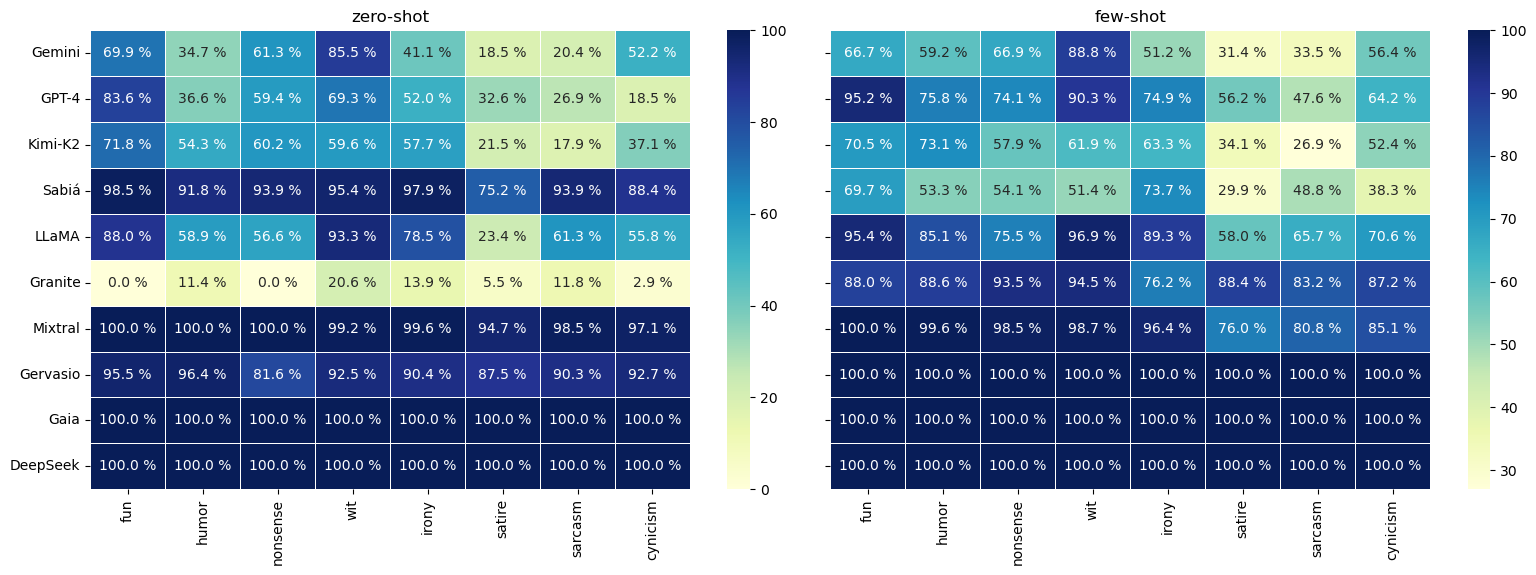

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Definição das Ordens e Dados Necessários ---

# ✅ MODELOS DESEJADOS EM ORDEM (Eixo Y)
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Mixtral',
    'Gervasio',
    'Gaia',
    'DeepSeek'
]

# ✅ ESTILOS CÔMICOS EM ORDEM (Eixo X)
comic_style_order = [
    'fun', 
    'humor', 
    'nonsense', 
    'wit', 
    'irony', 
    'satire', 
    'sarcasm',       
    'cynicism'
]

# Assunção: df_comic_styles está carregado.

# --- 2. Preparação dos Dados e Cálculo das Porcentagens ---

# Contagem 1: pred_label = 1
df_counts_1 = df_comic_styles[df_comic_styles['pred_label'] == 1]
df_counts_1 = df_counts_1.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_correct')

# Contagem 2: Total de Amostras
df_counts_total = df_comic_styles.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_total')

# Merge dos DataFrames
df_merged = pd.merge(df_counts_1, df_counts_total, on=['scenario', 'model_name', 'comic_style'], how='right').fillna(0)

# Cálculo da Porcentagem
df_merged['percentage'] = (df_merged['count_correct'] / df_merged['count_total']) * 100

# --- 3. Aplicação da Ordem de Exibição (Otimizada) ---

# 1. Definir a ordem para a pivotagem (Eixo Y)
# Usar model_order diretamente como categorias.
df_merged['model_name'] = pd.Categorical(df_merged['model_name'], categories=model_order, ordered=True)

# 2. Definir a ordem para a pivotagem (Eixo X)
df_merged['comic_style'] = pd.Categorical(df_merged['comic_style'], categories=comic_style_order, ordered=True)


# 4. Pivotar os dados e FORÇAR A ORDEM
# 4a. Pivotar os dados
pivot_data = df_merged.pivot_table(
    index='model_name',
    columns=['scenario', 'comic_style'],
    values='percentage',
    fill_value=0 
)

# 4b. ✅ CORREÇÃO DEFINITIVA: Reindexar para forçar a ordem no Eixo Y
# Usar model_order diretamente para garantir a ordem exata.
pivot_data = pivot_data.reindex(model_order)


# --- 5. Geração dos Subgráficos ---

scenarios = df_comic_styles['scenario'].unique()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plt.suptitle('', fontsize=16, y=1.02)

# 6. Iterar sobre os cenários e plotar cada subgráfico
for i, scenario in enumerate(scenarios):
    
    # Selecionar a fatia de dados correspondente ao cenário atual
    heatmap_data = pivot_data.xs(scenario, level='scenario', axis=1)
    
    # Criar o Mapa de Calor
    sns.heatmap(
        heatmap_data,
        ax=axes[i],        
        annot=True,        
        fmt=".1f",         
        cmap="YlGnBu",     
        linewidths=.5,
        cbar_kws={'label': ''} 
    )
    
    # Ajustar anotações para incluir o símbolo '%'
    for t in axes[i].texts: 
        t.set_text(t.get_text() + " %")
    
    # Configurar títulos e rótulos
    axes[i].set_title(f'{scenario.lower()}')
    
    axes[i].set_xlabel('') 
    if i == 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(visus_path, 'comic_styles_heatmap_by_scenario.png'), dpi=300, bbox_inches='tight')

In [20]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)
#results['model_name'] = results['model_name'].apply(lambda model_name: model_short_names[model_name])

In [21]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
"""     'Gaia',
    'Mixtral',
    'DeepSeek',
    'Gervasio' """
]

results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

C:\Users\jose-\AppData\Local\Temp\ipykernel_2000\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
C:\Users\jose-\AppData\Local\Temp\ipykernel_2000\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
C:\Users\jose-\AppData\Local\Temp\ipykernel_2000\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenar

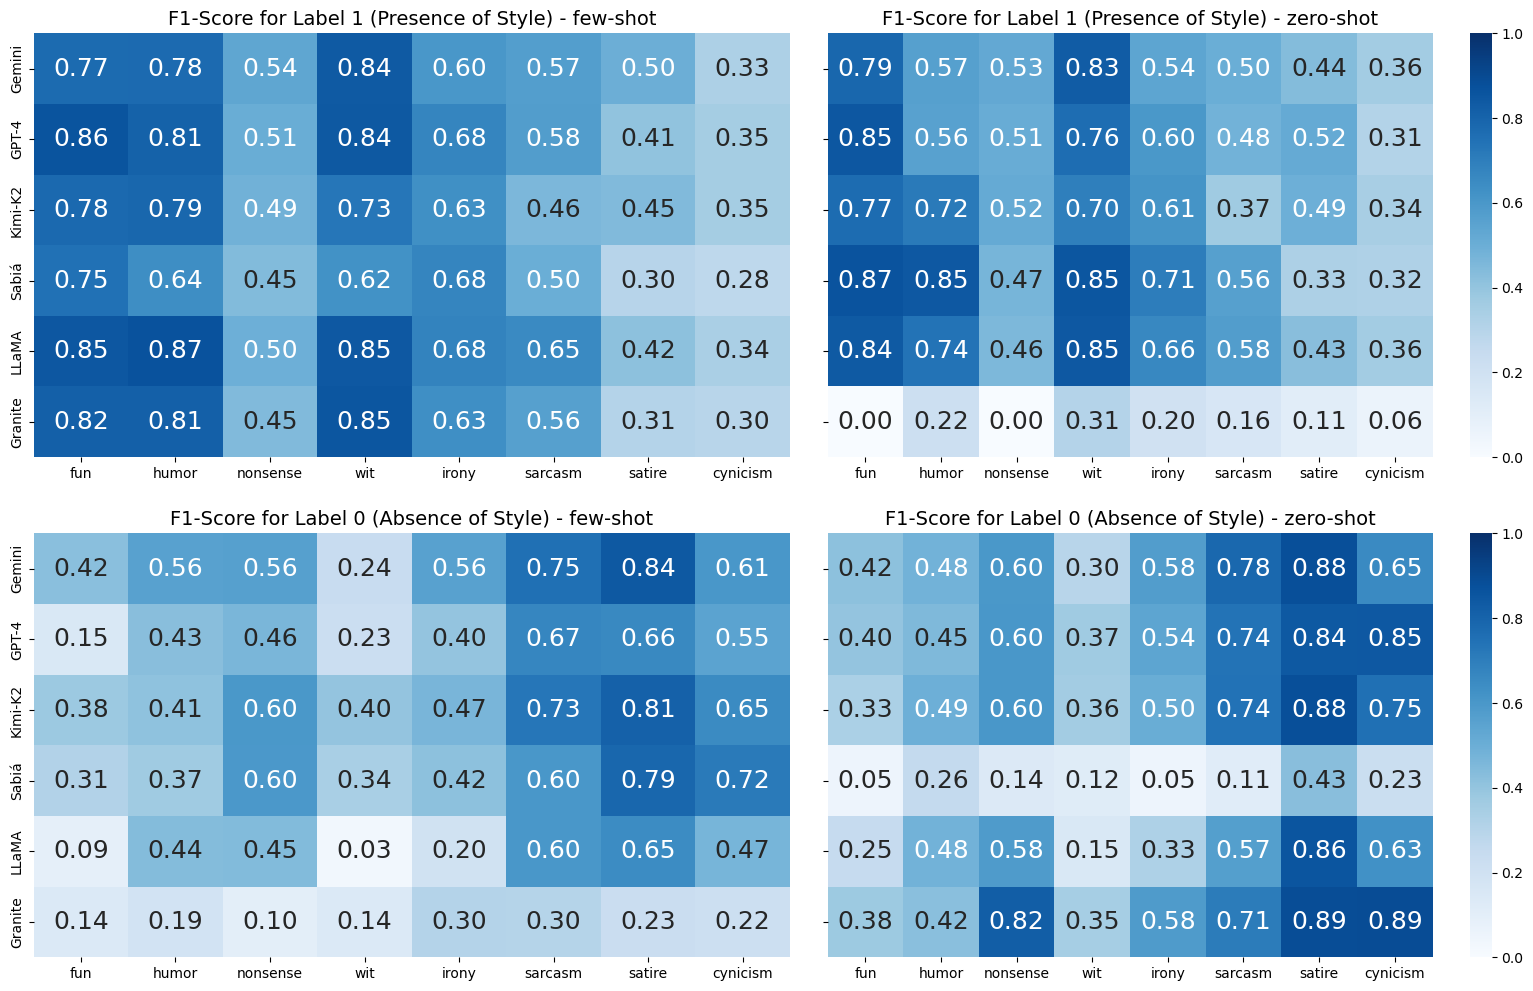

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'sarcasm', 'satire', 'cynicism']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot_table(
            index='model_name', columns='comic_style', values=f1_class, aggfunc='mean'
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 18},
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=14)
        ax.set_xlabel('', fontsize=16) 
        if col_idx == 0:
            ax.set_ylabel('', fontsize=16)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=10, rotation=0)
        ax.tick_params(axis='y', labelsize=10)

plt.subplots_adjust(hspace=0.18, wspace=0.05)

plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumindo que 'results' é o seu DataFrame e 'style_order' foi definido.
style_order = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'sarcasm', 'satire', 'cynicism']

# --- 1. Preparação dos Dados ---

# Derreter os dados (long format)
results_melted = results.melt(
    id_vars=['model_name', 'comic_style', 'scenario'], 
    value_vars=['f1_1', 'f1_0'], 
    var_name='f1_class', 
    value_name='F1_Score'
)

# Renomear os valores para rótulos legíveis
results_melted['f1_class'] = results_melted['f1_class'].map({
    'f1_1': 'Label 1 (Presença)', 
    'f1_0': 'Label 0 (Ausência)'
})

# Aplicar ordenação dos estilos (crucial para o layout)
results_melted['comic_style'] = pd.Categorical(
    results_melted['comic_style'], categories=style_order, ordered=True
)

# ✅ NOVO PASSO: Criar uma coluna combinada para ser usada como COLUNA no FacetGrid.
# Isso permite usar COL_WRAP, que era a sua intenção original.
results_melted['facet_col'] = results_melted['comic_style'].astype(str) + ' | ' + results_melted['f1_class']
# Para garantir que as classes F1 apareçam primeiro, podemos usar f1_class como linha
# Porém, se usarmos f1_class como linha, o col_wrap falha (erro anterior).
# Vamos forçar a quebra por estilo, mantendo a métrica como linha, mas ajustando o COL_WRAP.


# --- 2. Criação do Gráfico (Catplot) ---

g = sns.catplot(
    data=results_melted,
    x='model_name',
    y='F1_Score',
    hue='scenario',
    # Usar 'comic_style' para COL e 'f1_class' para ROW.
    # O COL_WRAP será aplicado à variável COL (comic_style).
    row='f1_class', 
    col='comic_style', 
    kind='bar',
    palette='deep',
    
    # ✅ AJUSTE AQUI: Quebrar as colunas em 4. 
    # Isso criará (2 linhas fixas) * (2 linhas de quebra) = 4 linhas de gráficos.
    col_wrap=4, 
    
    height=4,
    aspect=0.8,
    sharey=True
)

# --- 3. Ajustes de Layout ---

g.set_axis_labels("Modelo", "F1-Score Médio")

# Ajustar os títulos para ficarem mais limpos (mostra apenas o estilo cômico no topo)
# O rótulo da linha (f1_class) já é adicionado automaticamente pelo FacetGrid.
g.set_titles(col_template="{col_name}") 

g.set_xticklabels(rotation=45, ha='right')
g.fig.tight_layout(w_pad=1, h_pad=1) 
plt.show()

ValueError: Cannot use `row` and `col_wrap` together.

In [24]:
comic_styles = df_comic_styles['comic_style'].unique()

print(comic_styles)

# O código abaixo cria dois dataframe de para cada estilo cômico, um de piores casos e outro de melhores. 
# Ex.: df_fun_worse, df_fun_better, df_irony_worse, df_irony_better.

for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

['fun' 'humor' 'nonsense' 'wit' 'irony' 'satire' 'sarcasm' 'cynicism']


##### Humor Reasoning

In [25]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] >= BETTER_EXPLANATIONS_THRESHOLD]

In [26]:
expl_worse_summary = df_explanations_worse.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_worse_summary.columns = ['count', 'agreement_level']
expl_worse_summary = expl_worse_summary.reset_index()
expl_worse_summary = expl_worse_summary.sort_values(['model_name', 'scenario'])

print(expl_worse_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot    359            1.471
1             deepseek-r1-0528-qwen3-8b  zero-shot    256            1.625
2                      gemini-2.5-flash   few-shot     70            1.886
3                      gemini-2.5-flash  zero-shot     31            1.871
4              gemma-3-gaia-pt-br-4b-it   few-shot    207            1.749
5              gemma-3-gaia-pt-br-4b-it  zero-shot    164            1.701
6   gervasio-7b-portuguese-ptbr-decoder   few-shot    430            1.300
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot    435            1.186
8                                 gpt-4   few-shot     81            1.864
9                                 gpt-4  zero-shot     72            1.875
10              granite-3-3-8b-instruct   few-shot    161            1.739
11              granite-3-3-8b-instruct  zero-shot    147            1.789
12                       

In [27]:
expl_better_summary = df_explanations_better.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_better_summary.columns = ['count', 'agreement_level']
expl_better_summary = expl_better_summary.reset_index()
expl_better_summary = expl_better_summary.sort_values(['model_name', 'scenario'])

print(expl_better_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot     92            4.413
1             deepseek-r1-0528-qwen3-8b  zero-shot    176            4.398
2                      gemini-2.5-flash   few-shot    398            4.756
3                      gemini-2.5-flash  zero-shot    433            4.875
4              gemma-3-gaia-pt-br-4b-it   few-shot    226            4.588
5              gemma-3-gaia-pt-br-4b-it  zero-shot    262            4.523
6   gervasio-7b-portuguese-ptbr-decoder   few-shot     37            4.486
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     29            4.517
8                                 gpt-4   few-shot    379            4.702
9                                 gpt-4  zero-shot    384            4.797
10              granite-3-3-8b-instruct   few-shot    284            4.623
11              granite-3-3-8b-instruct  zero-shot    295            4.637
12                       